# In-Depth Exploratory Data Analysis (EDA)
## Netflix Content Analysis 🎬

**Project Objective:** This project performs an in-depth exploratory data analysis of the Netflix dataset. Explore trends in content production, identify popular genres, analyze content ratings, and understand the distribution of movies and TV shows on the platform. This project builds on foundational EDA by introducing time-series analysis and more complex data cleaning and transformation techniques.


### Core Concepts Covered:
1.  **Data Cleaning & Transformation:** Handling missing values and converting data types (especially dates).
2.  **Time-Series Analysis:** Analyzing how content has been added to Netflix over the years.
3.  **Text Data Manipulation:** Parsing and analyzing columns with multiple values, like `listed_in` (genres) and `cast`.
4.  **Geographical & Rating Analysis:** Understanding where content comes from and its maturity level.
5.  **Feature Engineering:** Creating new, insightful features like 'content age'.
6.  **Advanced Visualization:** Creating insightful plots to understand distributions and relationships in the data.

WordCloud visualizes the most frequent words appearing in Netflix content descriptions.

### Step 1: Setup - Importing Libraries

The analysis begins by importing the essential data science toolset, including the `wordcloud` library for text visualization.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# A consistent style is set for the plots.
sns.set_style('darkgrid')

### Step 2: Data Loading and Initial Inspection

The `netflix_titles.csv` dataset will be loaded and a high-level overview will be performed.

In [61]:
netflix_df = pd.read_csv('/netflix_titles.csv')

# Displaying the first 5 rows to verify
print("Dataset loaded successfully!")
netflix_df.head()

Dataset loaded successfully!


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [62]:
#A concise summary of the dataframe is obtained.
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


**Interpretation of `.info()`:**
- A total of **7787 entries (titles)** are present in the dataset.
- **Key Problem:** The `date_added` column is stored as an `object` type (string) instead of a `datetime` object. Time-based analysis cannot be performed until this issue is corrected.
- **Missing Values:** Missing values are present in the `director`, `cast`, `country`, `date_added`, and `rating` columns. The highest number of null values is observed in the `director` column.

### Step 3: Data Cleaning and Transformation

This step is considered critical for ensuring that the analysis is accurate. Missing values will be handled and data types will be corrected.

#### **Theoretical Concept: Data Type Conversion & Handling Nulls**

Data is often received in non-ideal formats. When dates are stored as strings, components such as the year or month cannot be extracted, and data cannot be plotted over time effectively. Therefore, columns must be converted to their appropriate data types (`pd.to_datetime`, `.astype()`), which is considered a fundamental preprocessing step.

For null values, several strategies can be applied:

1. **Drop:** If only a very small percentage of rows contain missing data, those rows can be removed using (`.dropna()`).
2. **Fill/Impute:** Missing values can be replaced with a placeholder (such as "Unknown") or with a statistical measure (such as the mode for categorical data). This method is useful when the remaining information in those rows should be preserved.

In [63]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [64]:
# 1. Handling of missing values in 'director' and 'cast'
# Since these are text fields and many values are missing, they are filled with 'Unknown'.
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [65]:
netflix_df['country'].mode()[0]

'United States'

In [66]:
netflix_df['country'].value_counts()

,count
country,
United States,2555
India,923
United Kingdom,397
Japan,226
South Korea,183
...,...
"Germany, United States, United Kingdom, Canada",1
"Peru, United States, United Kingdom",1
"Saudi Arabia, United Arab Emirates",1


In [67]:
# 2. Handling of missing 'country'
# The missing values are filled with the mode, which is the most common country.
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [68]:
# 3. Dropping the few rows with missing 'date_added' and 'rating'
# Since the number of such rows is small (less than 0.2% of the data), they are safely removed.
netflix_df.dropna(subset=['date_added', 'rating'], inplace=True)

In [69]:
# 4. Conversion of 'date_added' to datetime objects
# The parameter format='mixed' is used so that potential variations in date formats can be handled.
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


* **format='mixed':** With this argument, the date format is automatically inferred by pandas. This is useful when different date formats are present in the column.

* **dayfirst=False:** With this argument, when a date format is ambiguous (e.g., 01/02/2023), it is interpreted as month first (January 2nd) rather than day first (February 1st).

In [70]:
# 5. Creation of new features for year and month added
# The year and month are extracted from the 'date_added' column and converted to integers.

netflix_df['year_added'] = netflix_df['date_added'].dt.year.astype(int)
netflix_df['month_added'] = netflix_df['date_added'].dt.month.astype(int)

netflix_df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12


In [71]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
 12  year_added    7770 non-null   int64         
 13  month_added   7770 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(10)
memory usage: 910.5+ KB


In [72]:
# Verification of cleaning and transformation
print("Missing values after cleaning are displayed below:")
print(netflix_df.isnull().sum())

print("\nData types after transformation are displayed below:")
print(netflix_df.dtypes)

Missing values after cleaning are displayed below:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation are displayed below:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int64
month_added              int64
dtype: object


### Step 4: Exploratory Data Analysis & Visualization

#### 4.1 What is the distribution of content type?

In this analysis, the distribution of content types in the dataset is examined. The number of titles categorized as **Movies** and **TV Shows** is calculated. This analysis helps in understanding which type of content is more prevalent in the Netflix dataset.

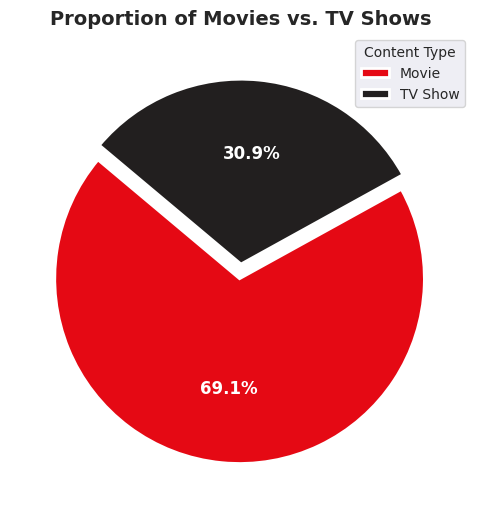

In [73]:
plt.figure(figsize=(8,6))

type_counts = netflix_df['type'].value_counts()

plt.pie(type_counts,
        autopct='%1.1f%%',
        startangle=140,
        explode=[0.08,0],
        colors=['#E50914','#221F1F'],
        textprops={'color':'white','fontsize':12,'weight':'bold'},
        wedgeprops={'edgecolor':'white','linewidth':2})

plt.title('Proportion of Movies vs. TV Shows', fontsize=14, weight='bold')

plt.legend(type_counts.index, title="Content Type", loc="best")

plt.ylabel('')
plt.show()

**Insight:** The Netflix library is largely dominated by Movies, which account for approximately 70% of the content in this dataset.

#### 4.2 How has content been added over time?

In this analysis, the number of titles added to Netflix over the years is examined. The dataset is grouped by **year_added** and **content type (Movie or TV Show)**. This helps in understanding how the volume of content added to Netflix has changed over time and whether Movies or TV Shows have contributed more to the growth of the platform.

<Figure size 1400x800 with 0 Axes>

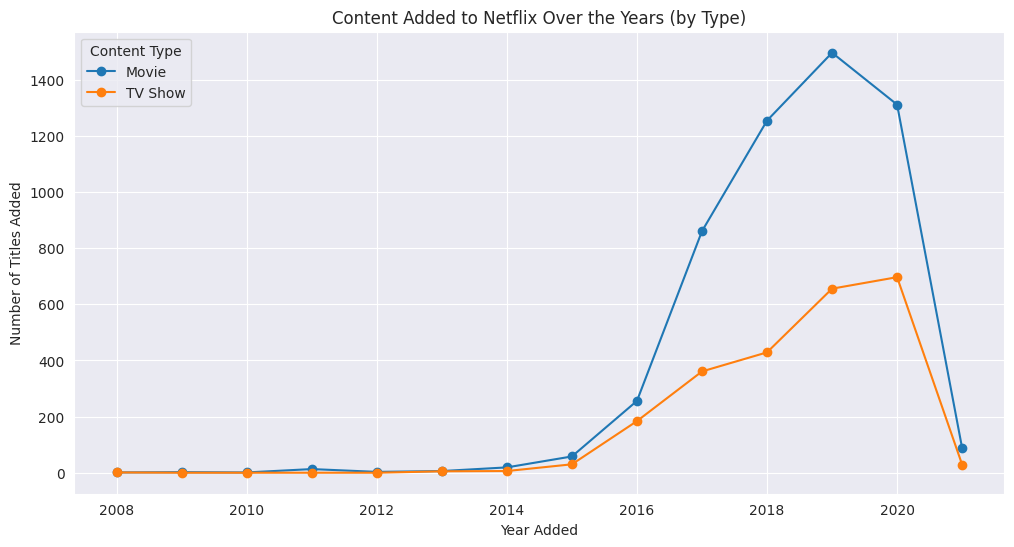

In [74]:
# Group data by year and content type
content_over_time = netflix_df.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Insight:** When Movies and TV Shows are analyzed separately, a significant increase in both categories can be observed over time. However, the addition of Movies increased more rapidly, reaching a peak around 2019. The growth in TV Shows appears to be more gradual and steady. A slight decline in the number of titles added during 2020 and 2021 is also observed, which may be attributed to the impact of the COVID-19 pandemic on production or the dataset being incomplete for the most recent year.

#### 4.3 What are the most popular genres?

In this analysis, the most common genres present in the Netflix dataset are identified. Since a title may belong to multiple genres, the `listed_in` column is separated and analyzed to determine the frequency of each genre. This helps in understanding which types of content are most prevalent on the platform.

In [75]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


#### **Handling Multi-Value Text Columns**

The `listed_in` column contains strings with multiple genres separated by commas (for example, "Dramas, International Movies"). To analyze each genre individually, the data must be transformed. A commonly used technique involves the following steps:

1. **Split:** The string in each row is split into a list of genres.
2. **Explode:** The DataFrame is expanded so that each genre in the list is placed in a separate row while the other information for that title is duplicated.

After this transformation, the frequency of each genre can be calculated using the `value_counts()` function.

In [76]:
# Split the 'listed_in' column and explode it
genres = netflix_df.assign(genre=netflix_df['listed_in'].str.split(', ')).explode('genre')

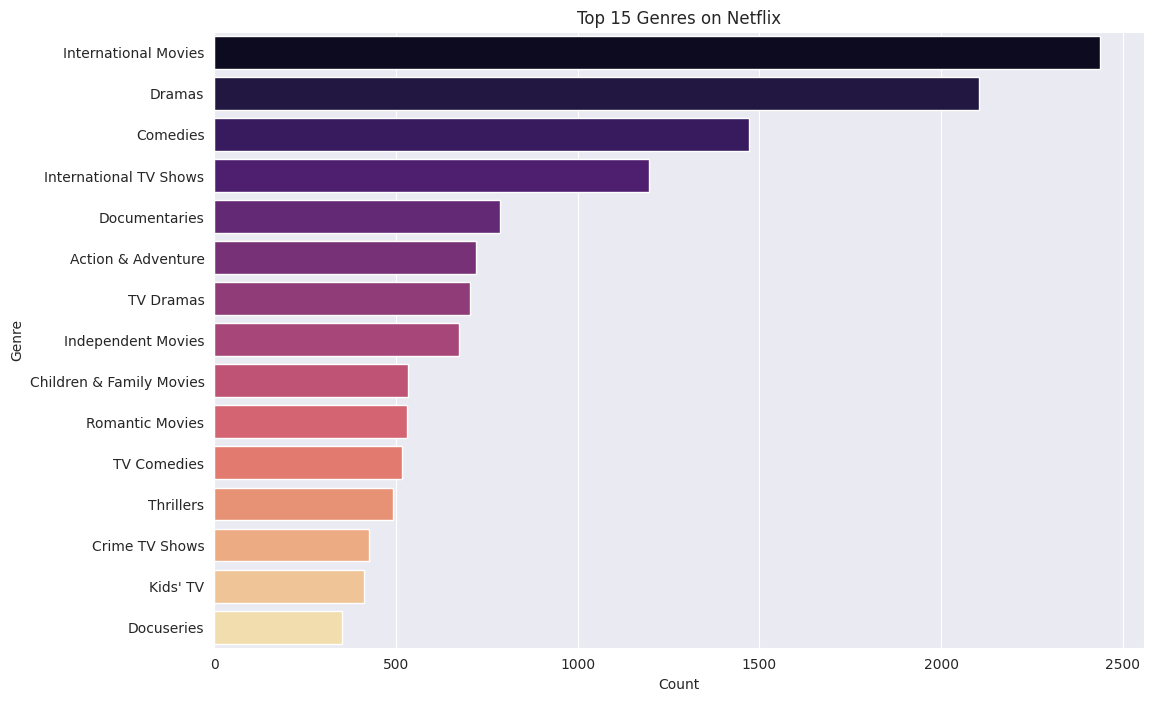

In [77]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count'] # Rename columns for clarity

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='magma', hue='genre', legend=False)
#https://seaborn.pydata.org/tutorial/color_palettes.html
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

**Insight:** "International Movies" is the most common genre tag, highlighting Netflix's global content strategy. This is followed by Dramas, Comedies, and Action & Adventure.

#### 4.4 What is the distribution of content duration?

In [78]:
# Separate movies and TV shows
movies_df = netflix_df[netflix_df['type'] == 'Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type'] == 'TV Show'].copy()

In [79]:
# Clean and convert duration for movies
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# Clean and convert duration for TV shows
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

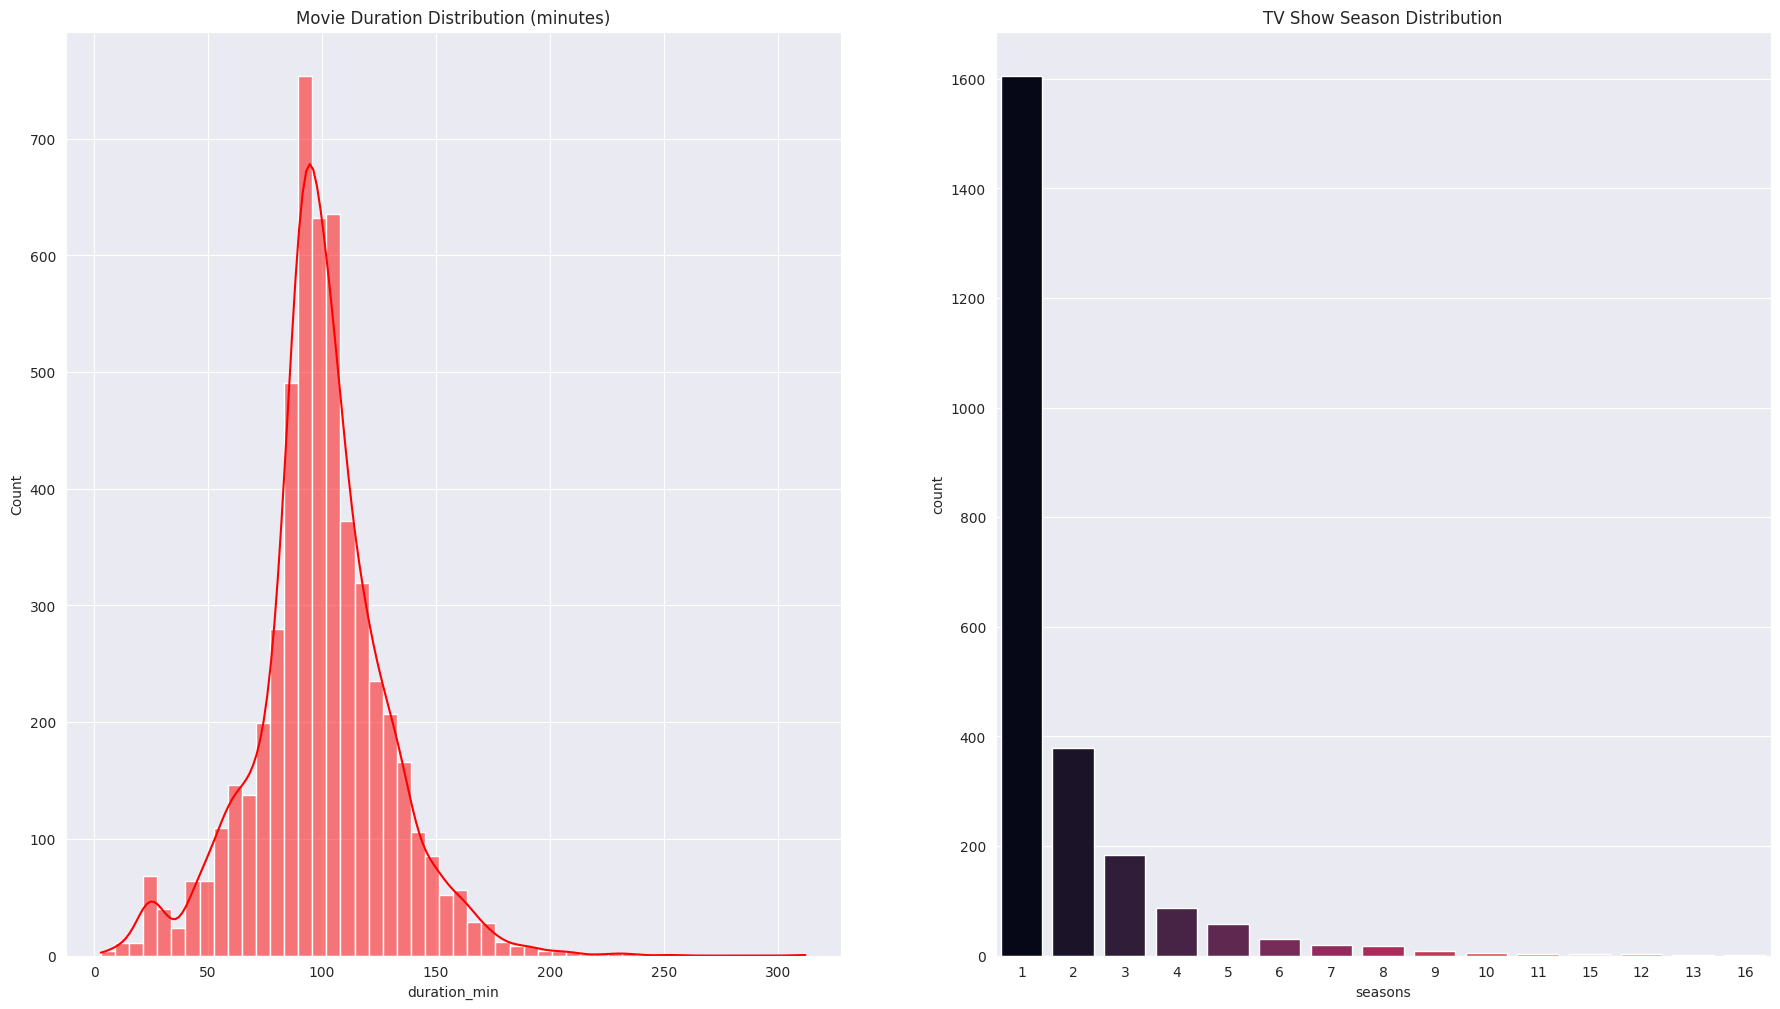

In [80]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(22, 12))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='red').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket', order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

**Insight:**
- The majority of movies on Netflix are between 80 and 120 minutes long, which is standard for feature films.
- The vast majority of TV shows on Netflix are short-lived, with most having only 1 season. This could reflect a strategy of producing many pilots and only renewing the most successful ones, or a focus on limited series.


### 4.5 Where does the content come from? (Geographical Analysis)

In [81]:
# Handle the multi-country listings similar to genres
countries = netflix_df.assign(country=netflix_df['country'].str.split(', ')).explode('country')

In [82]:
# Get the top 15 countries and their counts
top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity

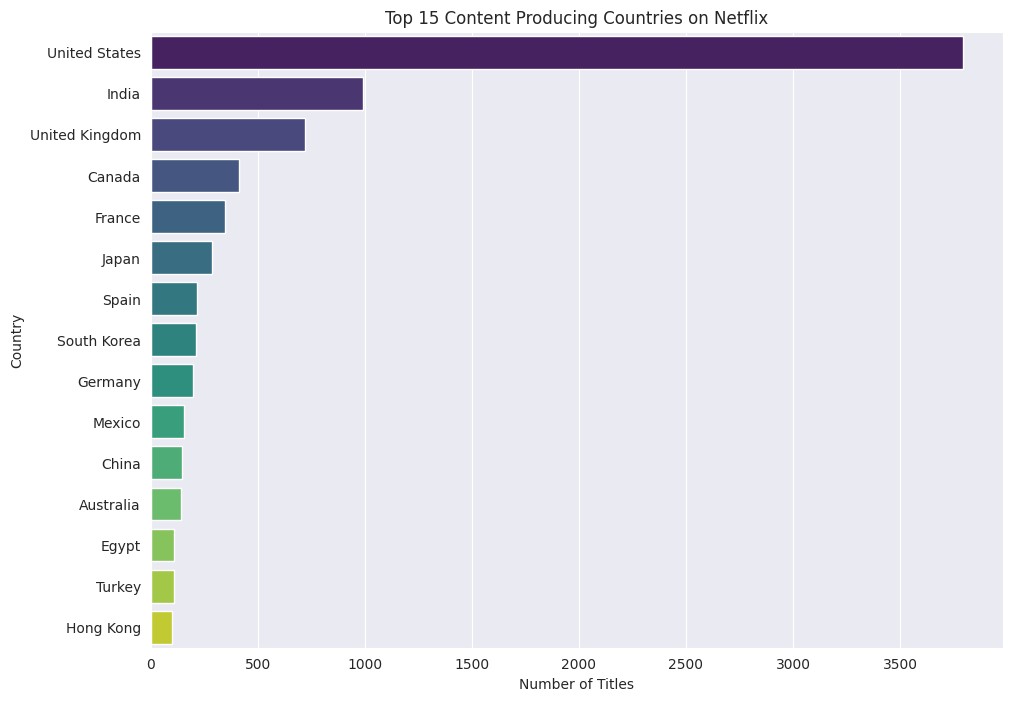

In [83]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(11, 8))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insight:** The United States is by far the largest producer of content available on Netflix. However, India is a very strong second, which explains why so many of the top actors were from India. The UK, Japan, and South Korea also represent major content markets for the platform, emphasizing its global nature.

In [84]:
!pip install plotly

In [85]:
import plotly.express as px

# Count titles per country
country_counts = countries['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

# Apply log scale
country_counts['log_count'] = np.log1p(country_counts['count'])

fig = px.choropleth(
    country_counts,
    locations="country",
    locationmode="country names",
    color="log_count",
    hover_name="country",
    hover_data={"count": True, "log_count": False},
    color_continuous_scale="turbo",
    title="Global Distribution of Netflix Content by Country"
)

fig.show()

**Insight:** The geographical analysis shows that the United States is the largest contributor of content available on Netflix. India emerges as the second-largest contributor, indicating a significant presence of Indian productions on the platform. Countries such as the United Kingdom, Japan, and South Korea also contribute a considerable amount of content, highlighting the global diversity of Netflix's library.

In [86]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


### 4.6 What are the maturity ratings of the content?

In this analysis, the distribution of maturity ratings assigned to Netflix titles is examined. The `rating` column indicates the age suitability of the content, such as TV-MA, TV-14, PG-13, and others. By analyzing the frequency of these ratings, insights can be gained into the types of audiences that the content on Netflix is primarily targeted toward.

In [87]:
netflix_df['rating'].value_counts()

,count
rating,
TV-MA,2861
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


In [88]:
rating_counts = netflix_df['rating'].value_counts().reset_index()
rating_counts.columns = ['rating','count']

fig = px.scatter(
    rating_counts,
    x='rating',
    y='count',
    size='count',
    color='rating',
    size_max=60,
    title='Distribution of Netflix Content Ratings'
)

fig.show()

### 4.7 How has the distribution of content ratings changed over time?

In this analysis, the changes in the distribution of content ratings over the years are examined. The dataset is grouped by **year_added** and **rating** to observe how the number of titles within each maturity rating category has evolved over time. This helps in understanding whether Netflix has increasingly focused on certain audience groups, such as mature viewers or younger audiences, across different years.

<Figure size 1400x800 with 0 Axes>

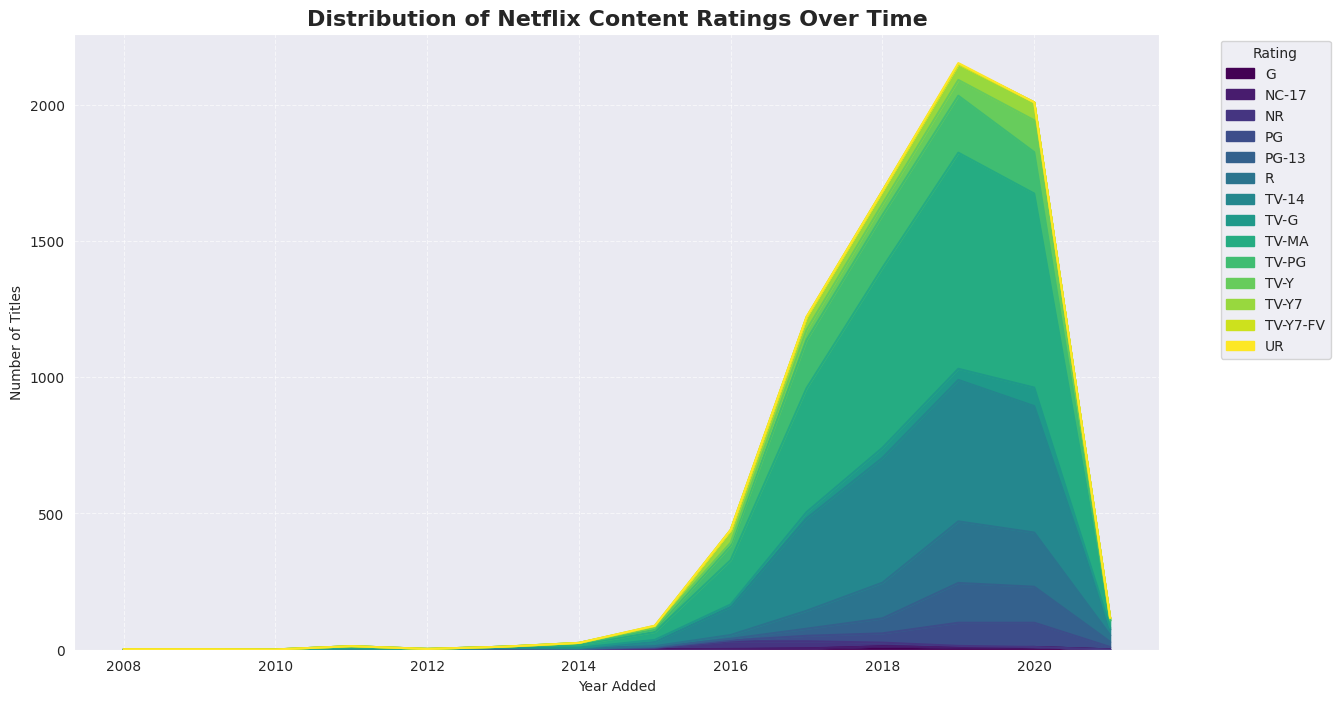

In [89]:
# Group data by year and rating
rating_over_time = netflix_df.groupby(['year_added','rating']).size().unstack().fillna(0)

# Plot stacked area chart
plt.figure(figsize=(14,8))

rating_over_time.plot(
    kind='area',
    stacked=True,
    figsize=(14,8),
    colormap='viridis'
)

plt.title('Distribution of Netflix Content Ratings Over Time', fontsize=16, weight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Rating', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Insight:** The chart shows that the number of titles added to Netflix increased rapidly after 2016, reaching a peak around 2019. Among all maturity ratings, **TV-MA** clearly dominates the platform, followed by **TV-14**, indicating that Netflix primarily focuses on content aimed at mature and teenage audiences. Ratings such as **PG**, **TV-PG**, and **R** contribute a moderate portion of the catalog, while ratings intended for children (such as **TV-Y** and **TV-Y7**) represent a much smaller share. A noticeable drop in 2021 is observed, which is likely due to the dataset being incomplete for that year or reduced content additions.

## 4.8 Is there a relationship between content age and its type (Movie vs. TV Show)?

In this analysis, the relationship between **content age** and **content type (Movie or TV Show)** is examined. Content age is calculated as the difference between the **year the content was added to Netflix (`year_added`)** and the **original release year (`release_year`)**. By comparing the distribution of content age for Movies and TV Shows, it can be determined whether newer or older content is more commonly added to Netflix for each content type.

/tmp/ipykernel_831/3371562692.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




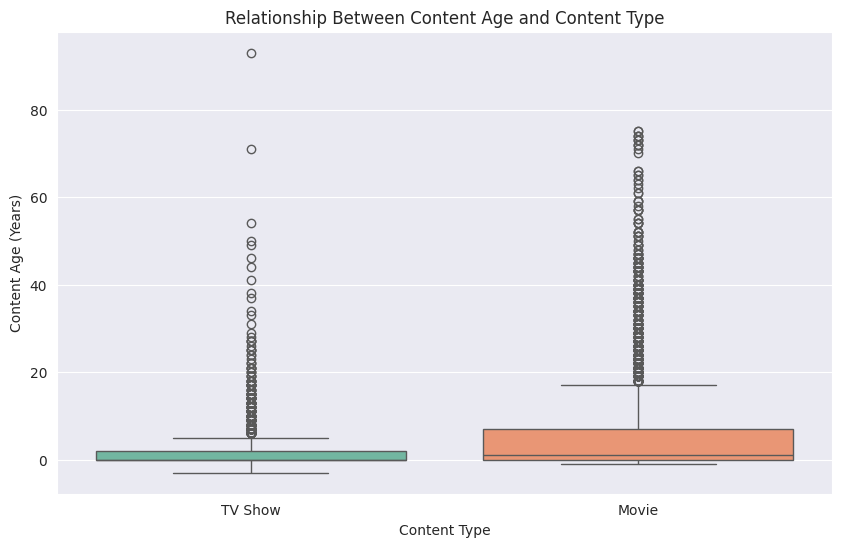

In [90]:
# Create content age feature
netflix_df['content_age'] = netflix_df['year_added'] - netflix_df['release_year']

plt.figure(figsize=(10,6))

sns.boxplot(x='type', y='content_age', data=netflix_df, palette='Set2')

plt.title('Relationship Between Content Age and Content Type')
plt.xlabel('Content Type')
plt.ylabel('Content Age (Years)')
plt.show()

**Insight:** The visualization shows that Movies have a much wider range of content ages compared to TV Shows. Many Movies on Netflix were released several years or even decades before being added to the platform, indicating that Netflix frequently acquires older films for its catalog. In contrast, TV Shows tend to have a much smaller content age, suggesting that most series are added to Netflix relatively soon after their original release.

### 4.9 Can we identify any trends in content production based on the release year vs. the year added to Netflix?

In this analysis, the relationship between the **release year of the content** and the **year it was added to Netflix** is examined. By comparing these two variables, trends can be identified regarding whether Netflix tends to add newly released content soon after its release or acquire older content from previous years. This analysis helps in understanding patterns in Netflix’s content acquisition strategy over time.

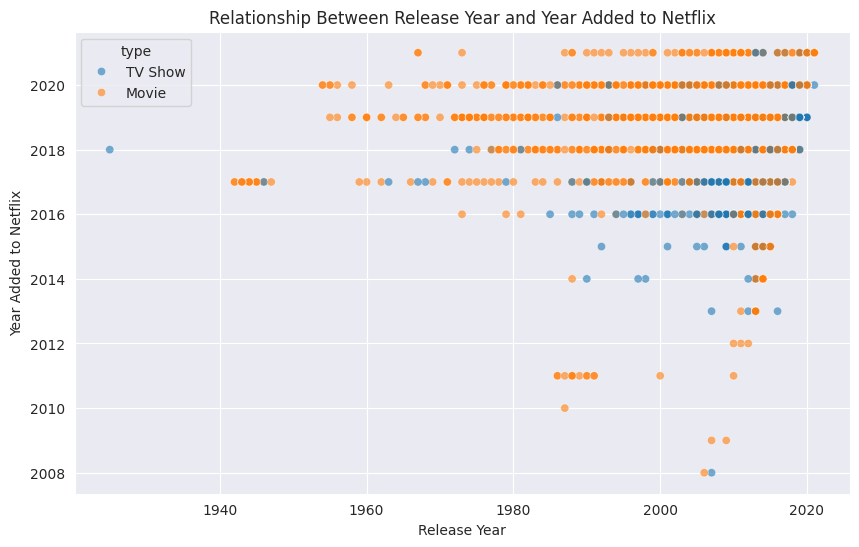

In [91]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=netflix_df,
    x='release_year',
    y='year_added',
    hue='type',
    alpha=0.6
)

plt.title('Relationship Between Release Year and Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.show()

In [92]:
#ploty
fig = px.scatter(
    netflix_df,
    x='release_year',
    y='year_added',
    color='type',
    title='Relationship Between Release Year and Year Added to Netflix',
    labels={
        'release_year': 'Release Year',
        'year_added': 'Year Added to Netflix'
    },
    opacity=0.6
)

fig.show()

**Insight:** The scatter plot shows that most titles added to Netflix were released in recent years, particularly after 2000, indicating a strong focus on relatively modern content. A noticeable clustering is observed where the release year and the year added are close, suggesting that many titles are added to Netflix shortly after their release. However, some points appear far to the left of the graph, showing that older movies and TV shows are also added to the platform, indicating that Netflix occasionally acquires classic or previously released content to diversify its library.

### 4.10 Who are the top directors on Netflix?

In this analysis, the directors who have contributed the highest number of titles to the Netflix catalog are identified. The `director` column is examined and the frequency of each director is calculated. This helps in understanding which directors have the most content available on the platform.

In [93]:
# Get top 10 directors excluding unknown
# Remove Unknown directors
directors_df = netflix_df[netflix_df['director'] != 'Unknown']

# Get top 10 directors
top_directors = directors_df['director'].value_counts().head(10).reset_index()

# Rename columns
top_directors.columns = ['director', 'count']

# Create treemap
fig = px.treemap(
    top_directors,
    path=['director'],
    values='count',
    color='count',
    color_continuous_scale='viridis',
    title='Top 10 Directors on Netflix'
)

fig.show()

**Insight:** The treemap highlights the directors who have contributed the highest number of titles to the Netflix catalog after excluding entries with unknown directors. Raúl Campos and Jan Suter appear as the most prominent contributors, followed by directors such as Marcus Raboy and Jay Karas. Many of these directors are associated with producing multiple projects, such as stand-up comedy specials or recurring genre content, which explains their higher number of titles on the platform. This indicates that Netflix often collaborates repeatedly with certain directors who consistently produce content for the platform.

### Step 5: Feature Engineering - Content Freshness

In this step, a new feature is created to analyze how old the content is when it is added to Netflix. This analysis helps in understanding the platform's acquisition strategy, such as whether older classic content is acquired or newly released content is added to the platform.

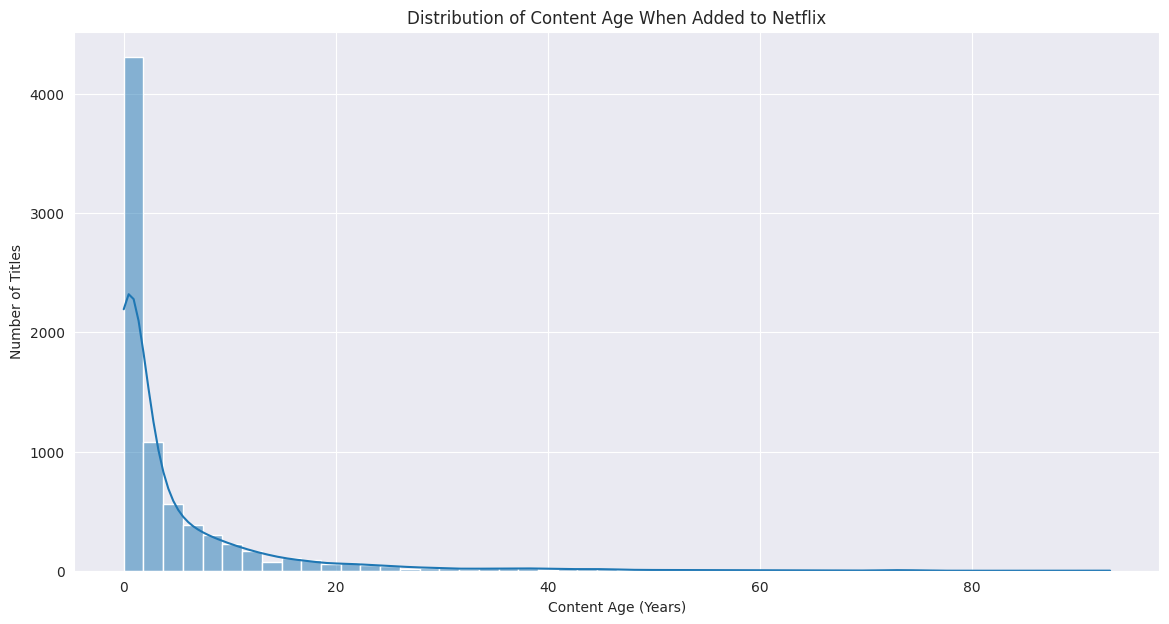

In [94]:
# Create the 'age_on_netflix' feature
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Filter out any potential errors where added_year is before release_year
content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

**Insight:** The large spike at `0` indicates that a significant portion of the content is added in the same year it is released, which is characteristic of "Netflix Originals." However, a long tail can also be observed, indicating that licensed content that may be decades old is also acquired by Netflix, contributing to the creation of a large library of classic films and shows.

### Step 6: Deeper Multivariate Analysis

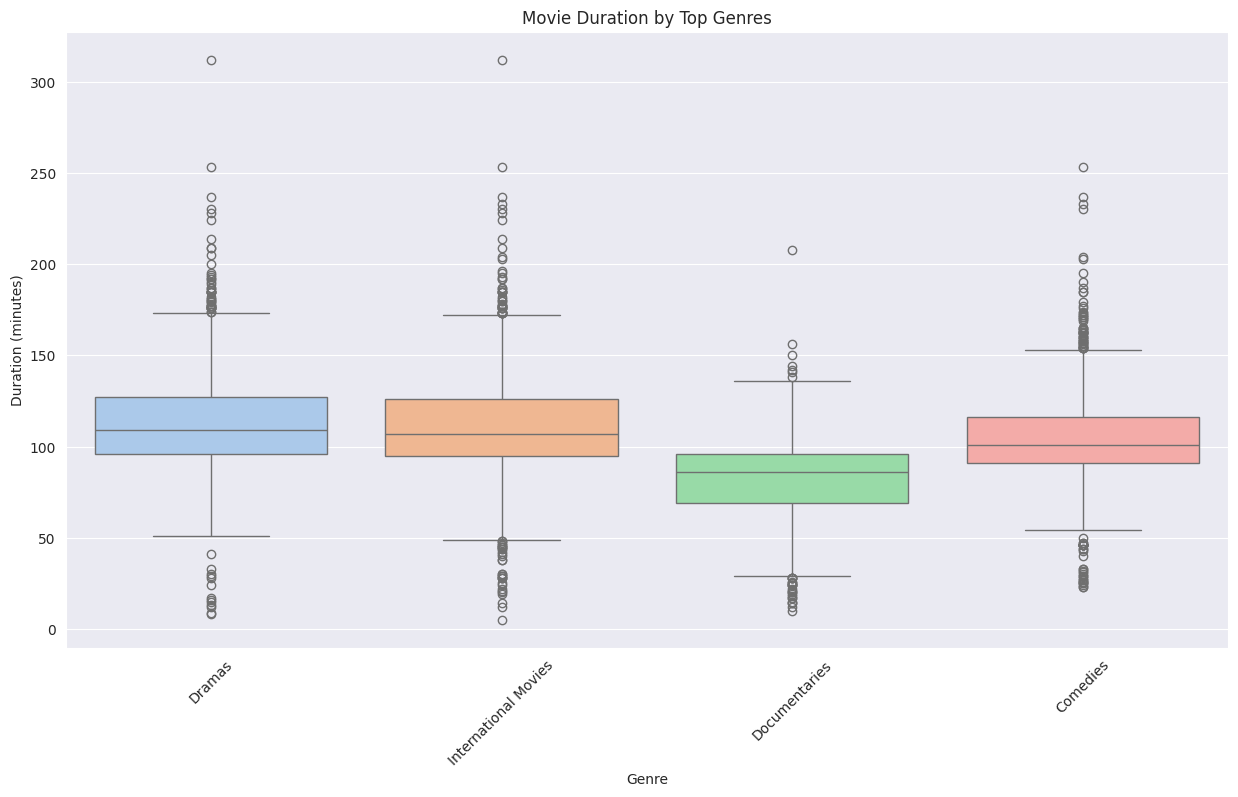

In [95]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

**Insight:** While the median duration for most top genres is observed to be similar (around 90–100 minutes), some variations can be identified. For example, a wider range of durations is observed in Dramas, with many films having longer runtimes. International Movies also exhibit a broad distribution, which reflects the diversity of filmmaking styles from different regions of the world.

### Step 7: Word Cloud from Content Descriptions

In this step, a word cloud is generated from the `description` column to identify the themes and words that are most frequently used in Netflix content descriptions.

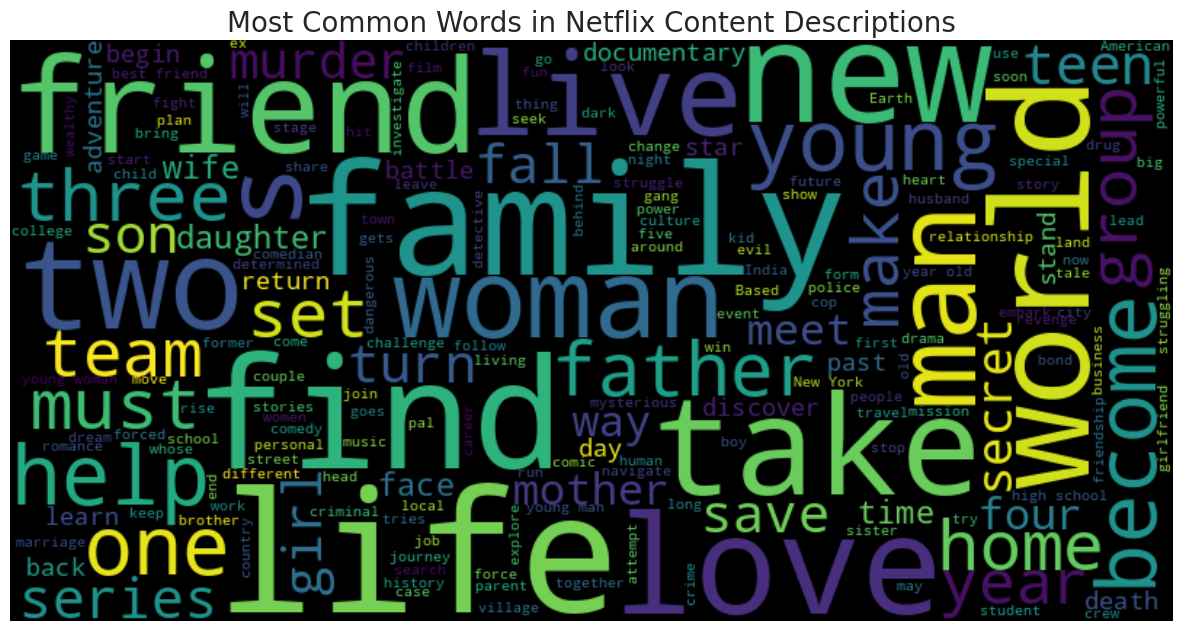

In [96]:
# Combine all descriptions into a single string
text = ' '.join(netflix_df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

**Insight:** The word cloud highlights common themes and subjects present in Netflix content descriptions. Words such as "life," "family," "love," "young," "friends," and "world" are prominently observed, suggesting that much of the content focuses on human relationships and personal journeys. Action-oriented words such as "find," "secret," and "new" are also frequently observed.

### Step 8: Final Conclusion and Summary of Insights

This exploratory data analysis of the Netflix dataset provides several insights into the composition and strategy of the platform's content library.

**Key Findings:**

1. **Content Strategy:** The Netflix library is largely dominated by Movies, which account for approximately 70% of the titles in the dataset. A significant increase in content additions is observed between 2016 and 2019. The platform appears to follow a mixed strategy that includes releasing new original content and acquiring older licensed content.

2. **Global Presence:** Although the United States contributes the largest number of titles, Netflix demonstrates a strong international presence. Countries such as India, the United Kingdom, and others also contribute a considerable amount of content, highlighting the platform’s global reach.

3. **Target Audience:** The majority of content is rated **TV-MA** and **TV-14**, indicating that much of the Netflix catalog is targeted toward mature and teenage audiences rather than younger children.

4. **Content Format and Genre:** Genres such as **Dramas**, **Comedies**, and **International Movies** are among the most common categories in the dataset. Most movies have durations between **90 and 120 minutes**, while many TV shows consist of a limited number of seasons, suggesting a tendency toward shorter series formats.

5. **Common Themes:** The analysis of content descriptions shows that themes such as **life, family, relationships, and personal journeys** appear frequently, reflecting common storytelling patterns across Netflix titles.

**Limitations:**  
It should be noted that this dataset represents a snapshot of Netflix’s catalog at a specific point in time and does not include viewership or popularity metrics. Therefore, the analysis focuses on the **availability and characteristics of content** rather than its **audience demand or performance**. Despite this limitation, the analysis provides a comprehensive overview of the structure and evolution of Netflix’s content library.

### You can connect with me on [Linkedin](www.linkedin.com/in/bhavya-sree-22122006bs) if you like the content